In [7]:
%pip install --ignore-installed numpy==2.3


^C
Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
import os
import shutil
import IPython

print("Purging corrupted directories...")

# 1. Locate and forcefully delete corrupted numpy and ~umpy folders
for path in sys.path:
    if 'site-packages' in path and os.path.exists(path):
        for item in os.listdir(path):
            if item.lower().startswith("numpy") or item.lower().startswith("~umpy"):
                target = os.path.join(path, item)
                try:
                    if os.path.isdir(target):
                        shutil.rmtree(target)
                    else:
                        os.remove(target)
                    print(f"Successfully deleted: {target}")
                except Exception as e:
                    print(f"Could not delete {target}: {e}")

print("\nExecuting clean installation...")

# 2. Run the pip install programmatically
IPython.get_ipython().run_line_magic('pip', 'install numpy pandas shap matplotlib joblib scikit-learn')


Purging corrupted directories...
Successfully deleted: a:\Anaconda\Lib\site-packages\numpy
Successfully deleted: a:\Anaconda\Lib\site-packages\numpy-1.26.4.dist-info

Executing clean installation...
  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl (12.3 MB)
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pybuildingenergy 2.0.2 requires docutils==0.22.3, but you have docutils 0.19 which is incompatible.
pybuildingenergy 2.0.2 requires pandas==2.3.2, but you have pandas 3.0.2 which is incompatible.
streamlit 1.51.0 requires pandas<3,>=1.4.0, but you have pandas 3.0.2 which is incompatible.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from datetime import datetime

from sklearn.model_selection import train_test_split, GroupKFold, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import clone

import optuna
import xgboost as xgb
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# ========================= CONFIG =========================
DATA_PATH = r"A:\College\Thesis\SHD\USstock\comstock\baseline.parquet"
MODEL_SAVE_DIR = Path(r"A:\College\Thesis\Submission\models\comstock_5.7")
PLOTS_DIR = MODEL_SAVE_DIR / "plots"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
CV_FOLDS = 5
MIN_SAMPLES_PER_ZONE = 250
N_TRIALS_XGB = 30
N_TRIALS_CAT_GLOBAL = 15  
N_TRIALS_CAT_ZONE   = 30 
N_TRIALS_LGB = 30
USE_LOG_TARGET = True
TRAIN_GLOBAL = True
TRAIN_PER_ZONE = True
FT2_PER_M2 = 10.7639104167
EARLY_STOPPING_ROUNDS = 50
MAX_ESTIMATORS = 2000
# ==========================================================

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")

def make_actual_vs_pred_plot(y_true, y_pred, title, out_path):
    plt.figure(figsize=(7, 7))
    plt.scatter(y_true, y_pred, s=8, alpha=0.35)
    mn = min(np.min(y_true), np.min(y_pred))
    mx = max(np.max(y_true), np.max(y_pred))
    plt.plot([mn, mx], [mn, mx], "r--", linewidth=2)
    plt.xlabel("Actual specific heating demand (kWh/m²/yr)")
    plt.ylabel("Predicted specific heating demand (kWh/m²/yr)")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=220)
    plt.close()

def get_cv(groups, n_splits=5, random_state=42):
    if groups is not None:
        return GroupKFold(n_splits=n_splits)
    return KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

def randomize_groups(groups, random_state=42):
    rng = np.random.RandomState(random_state)
    uniq = np.unique(groups)
    shuffled = rng.permutation(uniq)
    mapping = {g: i for i, g in enumerate(shuffled)}
    return np.vectorize(mapping.get)(groups)

def build_preprocess_ohe(numeric_features, categorical_features):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

def fit_transform_catboost(X, num_feats, cat_feats):
    num_imp = SimpleImputer(strategy="median")
    cat_imp = SimpleImputer(strategy="constant", fill_value="__MISSING__")

    X_num = pd.DataFrame(num_imp.fit_transform(X[num_feats]), columns=num_feats, index=X.index)
    X_cat = pd.DataFrame(cat_imp.fit_transform(X[cat_feats]), columns=cat_feats, index=X.index).astype("string")

    X_out = pd.concat([X_num, X_cat], axis=1)
    cat_feature_indices = [X_out.columns.get_loc(c) for c in cat_feats]
    return X_out, num_imp, cat_imp, cat_feature_indices

def transform_catboost(X, num_feats, cat_feats, num_imp, cat_imp):
    X_num = pd.DataFrame(num_imp.transform(X[num_feats]), columns=num_feats, index=X.index)
    X_cat = pd.DataFrame(cat_imp.transform(X[cat_feats]), columns=cat_feats, index=X.index).astype("string")
    X_out = pd.concat([X_num, X_cat], axis=1)
    return X_out

print("=== Loading parquet ===")
df = pd.read_parquet(DATA_PATH).convert_dtypes()
if df.index.name == "bldg_id" or "bldg_id" not in df.columns:
    df = df.reset_index()
print(f"Raw shape: {df.shape}")

# ---------------- Target ----------------
if "calc.enduse_group.site_energy.heating.energy_consumption..kwh" in df.columns:
    df["heating_energy_kwh"] = safe_numeric(df["calc.enduse_group.site_energy.heating.energy_consumption..kwh"])
else:
    parts = [
        "out.electricity.heating.energy_consumption",
        "out.natural_gas.heating.energy_consumption",
        "out.other_fuel.heating.energy_consumption",
        "out.district_heating.heating.energy_consumption",
    ]
    s = 0
    for c in parts:
        if c in df.columns:
            s = s + safe_numeric(df[c]).fillna(0.0)
    df["heating_energy_kwh"] = s

df["floor_area_ft2"] = safe_numeric(df["in.sqft"])

if "out.params.building_fraction_heated" in df.columns:
    df["building_fraction_heated"] = safe_numeric(df["out.params.building_fraction_heated"]).fillna(1.0)
else:
    df["building_fraction_heated"] = 1.0

df["floor_area_ft2"] = df["floor_area_ft2"] * df["building_fraction_heated"]

df = df.dropna(subset=["heating_energy_kwh", "floor_area_ft2"]).copy()
df = df[(df["floor_area_ft2"] > 0) & (df["heating_energy_kwh"] >= 0)].copy()
df["floor_area_m2"] = df["floor_area_ft2"] / FT2_PER_M2

df["specific_heat_demand_kwh_m2"] = df["heating_energy_kwh"] / df["floor_area_m2"]
df = df[np.isfinite(df["specific_heat_demand_kwh_m2"])].copy()

if "upgrade" in df.columns:
    u = df["upgrade"].astype("string").str.strip().str.lower()
    is_baseline = (u.isin(["0", "00", "baseline", "base", "upgrade00"]) | u.str.fullmatch(r"0+"))
    if is_baseline.sum() > 1000:
        df = df[is_baseline].copy()

CLIMATE_COL = "in.building_america_climate_zone"

# ---------------- Numeric coercion ----------------
# All column names corrected to match actual parquet suffixes
numeric_cols = [
    "out.params.hdd65f",
    "out.params.average_wall_u_value..btu_per_ft2_f_hr",
    "out.params.average_roof_u_value..btu_per_ft2_f_hr",
    "out.params.average_window_u_value..btu_per_ft2_f_hr",
    "out.params.ext_wall_area..m2",
    "out.params.ext_roof_area..m2",
    "out.params.ext_window_area..m2",
    "out.params.average_outdoor_air_fraction",
    "out.params.design_outdoor_air_flow_rate..m3_per_m2_s",
    "in.weekday_operating_hours..hr",
    "in.weekend_operating_hours..hr",
    "in.weekday_opening_time..hr",
    "in.weekend_opening_time..hr",
    "in.airtightness..m3_per_m2_s",  # infiltration heat loss proxy, m³/m²/s at 75Pa
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = safe_numeric(df[c])

# ---------------- Derived features ----------------

# 1. operating_hours_week
if {"in.weekday_operating_hours..hr", "in.weekend_operating_hours..hr"}.issubset(df.columns):
    df["operating_hours_week"] = (
        5.0 * df["in.weekday_operating_hours..hr"] + 2.0 * df["in.weekend_operating_hours..hr"]
    )

# 2. ventilation load proxy
if "out.params.design_outdoor_air_flow_rate..m3_per_m2_s" in df.columns:
    if "operating_hours_week" in df.columns:
        df["ventilation_load_proxy"] = (
            df["out.params.design_outdoor_air_flow_rate..m3_per_m2_s"] * df["operating_hours_week"]
        )
    else:
        df["ventilation_load_proxy"] = df["out.params.design_outdoor_air_flow_rate..m3_per_m2_s"]
elif {"out.params.average_outdoor_air_fraction", "operating_hours_week"}.issubset(df.columns):
    df["ventilation_load_proxy"] = (
        df["out.params.average_outdoor_air_fraction"] * df["operating_hours_week"]
    )

# 3. UA products
# Areas are already in m² from parquet; U-values are in BTU/hr·ft²·°F
# Multiply area m² → ft² to get UA in BTU/hr·°F
ua_terms = []
if {"out.params.average_wall_u_value..btu_per_ft2_f_hr", "out.params.ext_wall_area..m2"}.issubset(df.columns):
    df["UA_wall"] = (
        df["out.params.average_wall_u_value..btu_per_ft2_f_hr"]
        * (df["out.params.ext_wall_area..m2"] * FT2_PER_M2)
    )
    ua_terms.append("UA_wall")

if {"out.params.average_roof_u_value..btu_per_ft2_f_hr", "out.params.ext_roof_area..m2"}.issubset(df.columns):
    df["UA_roof"] = (
        df["out.params.average_roof_u_value..btu_per_ft2_f_hr"]
        * (df["out.params.ext_roof_area..m2"] * FT2_PER_M2)
    )
    ua_terms.append("UA_roof")

if {"out.params.average_window_u_value..btu_per_ft2_f_hr", "out.params.ext_window_area..m2"}.issubset(df.columns):
    df["UA_win"] = (
        df["out.params.average_window_u_value..btu_per_ft2_f_hr"]
        * (df["out.params.ext_window_area..m2"] * FT2_PER_M2)
    )
    ua_terms.append("UA_win")

if ua_terms:
    df["UA_total"] = df[ua_terms].sum(axis=1)
    df["UA_per_area"] = df["UA_total"] / df["floor_area_m2"]

if "out.params.hdd65f" in df.columns and "UA_per_area" in df.columns:
    df["HDD65_x_UA_per_area"] = df["out.params.hdd65f"] * df["UA_per_area"]


# Infiltration load proxy — how much heat escapes through air leakage
# combining leakage rate with climate severity
if "in.airtightness..m3_per_m2_s" in df.columns and "out.params.hdd65f" in df.columns:
    df["infiltration_x_HDD"] = df["in.airtightness..m3_per_m2_s"] * df["out.params.hdd65f"]

# Infiltration relative to envelope tightness
# compares air leakage to conductive loss — high ratio = leakage dominated building
if "in.airtightness..m3_per_m2_s" in df.columns and "UA_per_area" in df.columns:
    df["infiltration_to_UA_ratio"] = df["in.airtightness..m3_per_m2_s"] / (df["UA_per_area"] + 1e-6)


#calculating shd
_BTU_TO_KWH  = 2.931e-4   # 1 BTU  = 2.931e-4 kWh
_RHO_CP      = 0.33e-3    # ρ·cp_air [kWh / (m³·K)]
_INF_DIV     = 20         # natural infiltration ≈ blower-door rate / 20
_ETA         = 0.85
_W_PER_OCC   = 80         # sensible metabolic rate [W/person], ASHRAE 55
 
# ── Transmission losses ──────────────────────────────────────
# UA_total [BTU/hr·°F] is the full-building envelope.
# Scale by building_fraction_heated so only the heated shell counts.
# HDD65 [°F·day] × 24 h/day = degree-hours; × BTU_TO_KWH / heated_m² → kWh/m²/yr
 
if "UA_total" in df.columns and "out.params.hdd65f" in df.columns:
    _UA_heated = df["UA_total"] * df["building_fraction_heated"]
    _q_trans = (_UA_heated * df["out.params.hdd65f"] * 24 * _BTU_TO_KWH
                / df["floor_area_m2"])
else:
    _q_trans = pd.Series(np.nan, index=df.index)
 
# ── Ventilation losses ───────────────────────────────────────
# ODA [m³/m²/s] is already area-normalised; only runs when occupied.
# HDD_K_hr = HDD65 [°F·day] / 1.8 × 24 → [K·hr/yr]
 
if ("out.params.design_outdoor_air_flow_rate..m3_per_m2_s" in df.columns
        and "out.params.hdd65f" in df.columns):
    _HDD_Khr = df["out.params.hdd65f"] / 1.8 * 24
    _f_occ   = (df["operating_hours_week"] * 52.18 / 8760).clip(0, 1) \
               if "operating_hours_week" in df.columns else 0.60
    _q_vent  = (_RHO_CP
                * df["out.params.design_outdoor_air_flow_rate..m3_per_m2_s"]
                * 3600 * _HDD_Khr * _f_occ)
else:
    _q_vent = pd.Series(0.0, index=df.index)
 
# ── Infiltration losses ──────────────────────────────────────
# in.airtightness..m3_per_m2_s [m³/m²/s at 75 Pa]; natural rate ≈ /20; year-round.
 
if "in.airtightness..m3_per_m2_s" in df.columns and "out.params.hdd65f" in df.columns:
    _HDD_Khr = df["out.params.hdd65f"] / 1.8 * 24
    _q_inf   = _RHO_CP * (df["in.airtightness..m3_per_m2_s"] / _INF_DIV) * _HDD_Khr
else:
    _q_inf = pd.Series(0.0, index=df.index)
 
# ── Internal gains ───────────────────────────────────────────
# Lighting + equipment [W/ft²] → [W/m²] via × FT2_PER_M2; × EFLH × 1e-3 → kWh/m²/yr
# Occupants [ppl/m²] × 80 W/ppl × EFLH × 1e-3 → kWh/m²/yr
 
_q_int = pd.Series(0.0, index=df.index)
 
_LPD  = "out.params.interior_lighting_power_density..w_per_ft2"
_LEFL = "out.params.interior_lighting_eflh..hr"
if _LPD in df.columns and _LEFL in df.columns:
    _q_int += (df[_LPD] * FT2_PER_M2 * df[_LEFL] * 1e-3).fillna(0)
 
_EPD  = "out.params.interior_electric_equipment_power_density..w_per_ft2"
_EEFL = "out.params.interior_electric_equipment_eflh..hr"
if _EPD in df.columns and _EEFL in df.columns:
    _q_int += (df[_EPD] * FT2_PER_M2 * df[_EEFL] * 1e-3).fillna(0)
 
_OCC  = "out.params.occupant_density_ppl_per_m_2..people_per_m2"
_OEFL = "out.params.occupant_eflh..hr"
if _OCC in df.columns and _OEFL in df.columns:
    _q_int += (df[_OCC] * _W_PER_OCC * df[_OEFL] * 1e-3).fillna(0)
 
# ── Assemble ─────────────────────────────────────────────────
# Rows where transmission is NaN (missing UA or HDD) stay NaN.
df["calculated_shd"] = np.where(
    _q_trans.notna(),
    (_q_trans.fillna(0) + _q_vent.fillna(0) + _q_inf.fillna(0)
     - _ETA * _q_int.fillna(0)).clip(lower=0),
    np.nan,
)


    
# ---------------- Feature lists ----------------
numeric_features = [
    "floor_area_m2",
    "out.params.hdd65f",
    "UA_total",
    "UA_per_area",
    "HDD65_x_UA_per_area",
    "operating_hours_week",
    "ventilation_load_proxy",
    "in.year_built",
    "out.params.average_outdoor_air_fraction",
    "in.weekday_opening_time..hr",       # fixed
    "in.weekend_opening_time..hr",       # fixed
    "infiltration_x_HDD",
    "in.number_of_stories", # Might be noise
    "in.rotation..degrees", # Might be noise
    "infiltration_to_UA_ratio",
    "calculated_shd",
    "out.params.hdd50f",
]
categorical_features = [
    "in.comstock_building_type",
    "in.comstock_building_type_group",
    "in.building_subtype",
    "in.hvac_heat_type",
    "in.hvac_category",
    "in.wall_construction_type",
    "in.window_type",
    "in.window_to_wall_ratio_category",
    "in.interior_lighting_generation", #could affect internal gains (?)
    "in.state_name",
]
numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]
features = numeric_features + categorical_features

df = df.dropna(subset=["specific_heat_demand_kwh_m2", CLIMATE_COL]).copy()
print(f"Rows ready: {len(df)}")
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")
print(f"Total features: {len(features)}")

# ---------------- Global split (building-ID based) ----------------
# Split on bldg_id so no building appears in both train and test.
# A random row-level split causes leakage because Comstock contains
# near-duplicate rows for the same building archetype.
if "bldg_id" in df.columns:
    _bldg_ids = df["bldg_id"].unique()
    _train_bldgs, _test_bldgs = train_test_split(
        _bldg_ids, test_size=0.20, random_state=RANDOM_STATE
    )
    train_idx = df[df["bldg_id"].isin(_train_bldgs)].index
    test_idx  = df[df["bldg_id"].isin(_test_bldgs)].index
    print(f"Split by bldg_id: {len(_train_bldgs):,} train buildings, {len(_test_bldgs):,} test buildings")
else:
    # Fallback: stratified row split if bldg_id unavailable
    counts = df[CLIMATE_COL].value_counts()
    stratify = df[CLIMATE_COL] if counts.min() >= 2 else None
    train_idx, test_idx = train_test_split(
        df.index, test_size=0.20, random_state=RANDOM_STATE, stratify=stratify
    )
    print("WARNING: bldg_id not found — falling back to row-level split (leakage risk)")

df_train = df.loc[train_idx].copy()
df_test  = df.loc[test_idx].copy()

# Clip outliers in TRAINING set only — test set is never filtered.
# Filtering test rows removes the hardest cases and inflates metrics.
q1 = df_train["specific_heat_demand_kwh_m2"].quantile(0.005)
q2 = df_train["specific_heat_demand_kwh_m2"].quantile(0.995)
df_train = df_train[
    (df_train["specific_heat_demand_kwh_m2"] >= q1) &
    (df_train["specific_heat_demand_kwh_m2"] <= q2)
].copy()
print(f"Train rows after outlier clip: {len(df_train):,} | Test rows (unfiltered): {len(df_test):,}")

# ---------------- Optuna tuning ----------------
def tune_model(model_name, param_space_fn, X_train, y_train, groups_train, num_feats, cat_feats, n_trials_cat=N_TRIALS_CAT_GLOBAL):
    cv = get_cv(groups_train, CV_FOLDS, RANDOM_STATE)
    groups_for_cv = randomize_groups(groups_train, RANDOM_STATE) if groups_train is not None else None

    pruner = optuna.pruners.MedianPruner(n_warmup_steps=1)
    study = optuna.create_study(direction="minimize", pruner=pruner)

    def objective(trial):
        params = param_space_fn(trial)
        rmses = []
        best_iters = []

        for fold_i, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train, groups_for_cv)):
            X_tr = X_train.iloc[tr_idx]
            y_tr = y_train[tr_idx]
            X_va = X_train.iloc[va_idx]
            y_va = y_train[va_idx]

            y_tr_fit = np.log1p(y_tr) if USE_LOG_TARGET else y_tr
            y_va_fit = np.log1p(y_va) if USE_LOG_TARGET else y_va

            if model_name in ("xgb", "lgb"):
                prep = clone(build_preprocess_ohe(num_feats, cat_feats))
                X_tr_p = prep.fit_transform(X_tr)
                X_va_p = prep.transform(X_va)

                if model_name == "xgb":
                    # early_stopping_rounds moved to constructor in XGBoost >= 2.0
                    model = xgb.XGBRegressor(
                        **params, n_estimators=MAX_ESTIMATORS, tree_method="hist",
                        n_jobs=-1, random_state=RANDOM_STATE,
                        early_stopping_rounds=EARLY_STOPPING_ROUNDS
                    )
                    model.fit(X_tr_p, y_tr_fit, eval_set=[(X_va_p, y_va_fit)], verbose=False)
                else:
                    model = LGBMRegressor(
                        **params, n_estimators=MAX_ESTIMATORS,
                        n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1
                    )
                    model.fit(X_tr_p, y_tr_fit, eval_set=[(X_va_p, y_va_fit)],
                              callbacks=[
                                  __import__("lightgbm").early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                                  __import__("lightgbm").log_evaluation(period=-1)
                              ])

                best_iter = getattr(model, "best_iteration_", None) or MAX_ESTIMATORS
                best_iters.append(best_iter)
                pred = model.predict(X_va_p)

            else:
                X_tr_p, num_imp, cat_imp, cat_idx = fit_transform_catboost(X_tr, num_feats, cat_feats)
                X_va_p = transform_catboost(X_va, num_feats, cat_feats, num_imp, cat_imp)

                model = CatBoostRegressor(
                    **params, iterations=MAX_ESTIMATORS,
                    verbose=0, random_seed=RANDOM_STATE
                )
                model.fit(X_tr_p, y_tr_fit, eval_set=(X_va_p, y_va_fit),
                          use_best_model=True, cat_features=cat_idx,
                          early_stopping_rounds=EARLY_STOPPING_ROUNDS)

                best_iter = getattr(model, "get_best_iteration", lambda: MAX_ESTIMATORS)()
                best_iters.append(best_iter)
                pred = model.predict(X_va_p)

            if USE_LOG_TARGET:
                pred = np.expm1(pred)
                pred = np.clip(pred, 0, None)

            rmses.append(rmse(y_va, pred))

            trial.report(float(np.mean(rmses)), step=fold_i)
            if trial.should_prune():
                raise optuna.TrialPruned()

        trial.set_user_attr("best_iters", best_iters)
        return float(np.mean(rmses))

    study.optimize(objective, n_trials={
        "xgb": N_TRIALS_XGB, "cat": n_trials_cat, "lgb": N_TRIALS_LGB
    }[model_name], show_progress_bar=False)

    best_iters = study.best_trial.user_attrs.get("best_iters", [MAX_ESTIMATORS])
    best_iter_avg = int(np.mean(best_iters))

    return study.best_params, study.best_value, best_iter_avg

# ---------------- Search spaces ----------------
def xgb_space(trial):
    return {
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "subsample": trial.suggest_float("subsample", 0.65, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "min_child_weight": trial.suggest_float("min_child_weight", 5.0, 40.0),
        "gamma": trial.suggest_float("gamma", 0.0, 15.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 30.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 60.0, log=True),
    }

def lgb_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 80),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 40, 300),
        "subsample": trial.suggest_float("subsample", 0.65, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 30.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 60.0, log=True),
    }

def make_cat_space(max_depth):
    def cat_space(trial):
        return {
            "depth": trial.suggest_int("depth", 4, max_depth),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 5.0, 60.0),
            "random_strength": trial.suggest_float("random_strength", 1.0, 12.0),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 6.0),
            "loss_function": "RMSE",
        }
    return cat_space


# ---------------- Final model fitting ----------------
def fit_final_model(model_name, params, best_iter, X_tr, y_tr, num_feats, cat_feats):
    y_tr_fit = np.log1p(y_tr) if USE_LOG_TARGET else y_tr

    if model_name in ("xgb", "lgb"):
        prep = clone(build_preprocess_ohe(num_feats, cat_feats))
        X_tr_p = prep.fit_transform(X_tr)

        if model_name == "xgb":
            model = xgb.XGBRegressor(
                **params, n_estimators=best_iter, tree_method="hist",
                n_jobs=-1, random_state=RANDOM_STATE
            )
        else:
            model = LGBMRegressor(
                **params, n_estimators=best_iter,
                n_jobs=-1, random_state=RANDOM_STATE
            )

        model.fit(X_tr_p, y_tr_fit)
        pipe = Pipeline([("preprocess", prep), ("model", model)])
        return pipe

    else:
        X_tr_p, num_imp, cat_imp, cat_idx = fit_transform_catboost(X_tr, num_feats, cat_feats)
        model = CatBoostRegressor(
            **params, iterations=best_iter,
            verbose=0, random_seed=RANDOM_STATE
        )
        model.fit(X_tr_p, y_tr_fit, cat_features=cat_idx)

        return {
            "num_feats": num_feats,
            "cat_feats": cat_feats,
            "num_imp": num_imp,
            "cat_imp": cat_imp,
            "model": model,
        }

def predict_pipe(pipe, X):
    if isinstance(pipe, dict):
        X_p = transform_catboost(X, pipe["num_feats"], pipe["cat_feats"],
                                 pipe["num_imp"], pipe["cat_imp"])
        pred = pipe["model"].predict(X_p)
    else:
        pred = pipe.predict(X)
    if USE_LOG_TARGET:
        pred = np.expm1(pred)
        pred = np.clip(pred, 0, None)
    return pred

# ---------------- Train + evaluate ----------------
def train_and_eval_all(df_tr, df_te, label, results, is_zone=False):
    num_feats = [c for c in numeric_features if c in df_tr.columns]
    cat_feats = [c for c in categorical_features if c in df_tr.columns]

    X_tr = df_tr[num_feats + cat_feats]
    y_tr = df_tr["specific_heat_demand_kwh_m2"].to_numpy(dtype=np.float64)
    X_te = df_te[num_feats + cat_feats]
    y_te = df_te["specific_heat_demand_kwh_m2"].to_numpy(dtype=np.float64)

    groups_tr = df_tr["bldg_id"].to_numpy() if "bldg_id" in df_tr.columns else None

    # Dynamic CatBoost settings based on dataset size
    n_samples = len(X_tr)
    cat_max_depth = 6 if (is_zone or n_samples < 100_000) else 7
    n_trials_cat = N_TRIALS_CAT_ZONE if is_zone else N_TRIALS_CAT_GLOBAL
    print(f"CatBoost: max_depth={cat_max_depth}, n_trials={n_trials_cat} (n={n_samples:,})")


    print(f"\n=== {label} ===")
    baseline_pred = np.full_like(y_te, np.median(y_tr), dtype=np.float64)
    baseline_rmse = rmse(y_te, baseline_pred)
    print(f"Baseline RMSE (median): {baseline_rmse:.3f}")

    xgb_best, xgb_cv, xgb_iter = tune_model("xgb", xgb_space, X_tr, y_tr, groups_tr, num_feats, cat_feats)
    cat_best, cat_cv, cat_iter = tune_model("cat", make_cat_space(cat_max_depth), X_tr, y_tr, groups_tr, num_feats, cat_feats, n_trials_cat=n_trials_cat)
    lgb_best, lgb_cv, lgb_iter = tune_model("lgb", lgb_space, X_tr, y_tr, groups_tr, num_feats, cat_feats)

    print(f"Best CV RMSE -> XGB:{xgb_cv:.3f} | CAT:{cat_cv:.3f} | LGB:{lgb_cv:.3f}")

    cv_scores = {"XGBoost": xgb_cv, "CatBoost": cat_cv, "LightGBM": lgb_cv}
    best_by_cv = min(cv_scores, key=cv_scores.get)

    models = {
        "XGBoost": ("xgb", xgb_best, xgb_iter),
        "CatBoost": ("cat", cat_best, cat_iter),
        "LightGBM": ("lgb", lgb_best, lgb_iter),
    }

    for name, (mtype, params, best_iter) in models.items():
        pipe = fit_final_model(mtype, params, best_iter, X_tr, y_tr, num_feats, cat_feats)

        preds = predict_pipe(pipe, X_te)
        preds_tr = predict_pipe(pipe, X_tr)

        mae = float(mean_absolute_error(y_te, preds))
        rmse_te = rmse(y_te, preds)
        r2 = float(r2_score(y_te, preds))
        rmse_tr = rmse(y_tr, preds_tr)

        print(f"{name:9s} | Train RMSE:{rmse_tr:8.3f} | Test RMSE:{rmse_te:8.3f} | "
              f"MAE:{mae:8.3f} | R²:{r2:7.4f}")

        joblib.dump(pipe, MODEL_SAVE_DIR / f"{name.lower()}_{label.replace(' ', '_')}.joblib")

        plot_path = PLOTS_DIR / f"actual_vs_pred_{label.replace(' ', '_')}_{name}.png"
        make_actual_vs_pred_plot(y_te, preds, f"{label} - {name}", plot_path)

        results.append({
            "run_id": run_id,
            "label": label,
            "model": name,
            "cv_rmse": cv_scores[name],
            "train_rmse": rmse_tr,
            "test_rmse": rmse_te,
            "mae": mae,
            "r2": r2,
            "baseline_rmse": baseline_rmse,
            "best_by_cv": (name == best_by_cv),
            "best_iter": best_iter,
        })

=== Loading parquet ===
Raw shape: (336149, 706)
Rows ready: 336149
Numeric features: ['floor_area_m2', 'out.params.hdd65f', 'UA_total', 'UA_per_area', 'HDD65_x_UA_per_area', 'operating_hours_week', 'ventilation_load_proxy', 'in.year_built', 'out.params.average_outdoor_air_fraction', 'in.weekday_opening_time..hr', 'in.weekend_opening_time..hr', 'infiltration_x_HDD', 'in.number_of_stories', 'in.rotation..degrees', 'infiltration_to_UA_ratio', 'calculated_shd', 'out.params.hdd50f']
Categorical features: ['in.comstock_building_type', 'in.comstock_building_type_group', 'in.building_subtype', 'in.hvac_heat_type', 'in.hvac_category', 'in.wall_construction_type', 'in.window_type', 'in.window_to_wall_ratio_category', 'in.interior_lighting_generation', 'in.state_name']
Total features: 27
Split by bldg_id: 268,919 train buildings, 67,230 test buildings
Train rows after outlier clip: 266,230 | Test rows (unfiltered): 67,230


In [5]:
_mask = df["calculated_shd"].notna()
print(f"calculated_shd : {_mask.sum():,} valid rows")
print(f"  median calc  : {df.loc[_mask, 'calculated_shd'].median():.1f} kWh/m²/yr")
print(f"  median actual: {df.loc[_mask, 'specific_heat_demand_kwh_m2'].median():.1f} kWh/m²/yr")
print(f"  Pearson r    : {df.loc[_mask, 'calculated_shd'].corr(df.loc[_mask, 'specific_heat_demand_kwh_m2']):.3f}")

calculated_shd : 336,149 valid rows
  median calc  : 42.1 kWh/m²/yr
  median actual: 51.2 kWh/m²/yr
  Pearson r    : 0.531


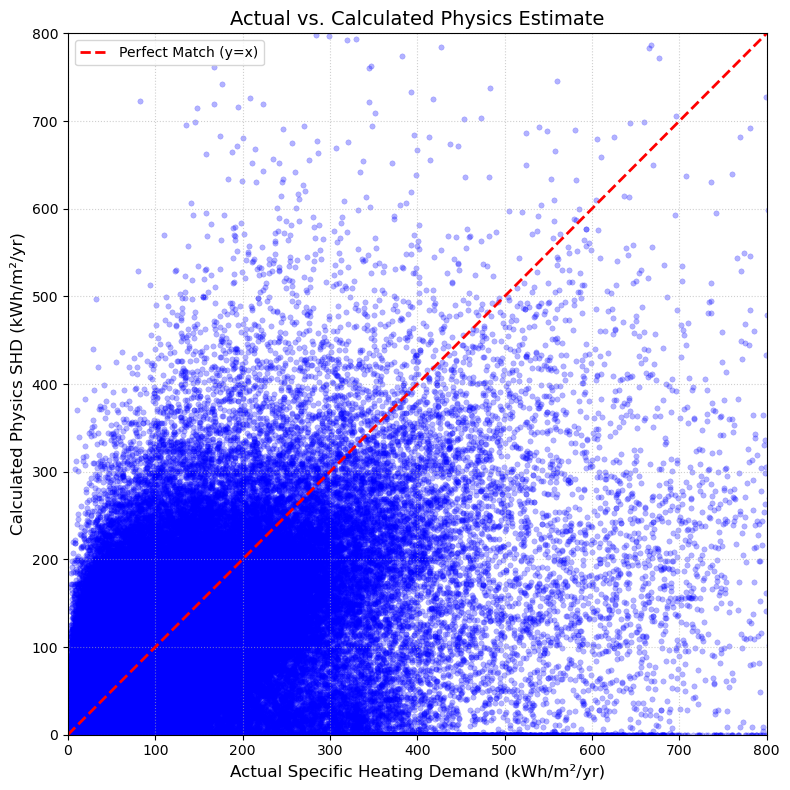

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Extract variables directly from the global dataframe
y_actual = df["specific_heat_demand_kwh_m2"]
y_calc = df["calculated_shd"]

plt.figure(figsize=(8, 8))

sns.scatterplot(x=y_actual, y=y_calc, alpha=0.3, s=15, edgecolor=None, color="blue")

# Calculate the bounds for the 1:1 line
# min_val = min(y_actual.min(), y_calc.min())
# max_val = max(y_actual.max(), y_calc.max())

# # Perfect match reference line
# plt.plot(
#     [min_val, max_val], [min_val, max_val], 
#     color='red', linestyle='--', linewidth=2, label='Perfect Match (y=x)'
# )

# Max 800
plt.xlim(0, 800)
plt.ylim(0, 800)
plt.plot(
    [0, 800], [0, 800], 
    color='red', linestyle='--', linewidth=2, label='Perfect Match (y=x)'
)
plt.xlabel("Actual Specific Heating Demand (kWh/m²/yr)", fontsize=12)
plt.ylabel("Calculated Physics SHD (kWh/m²/yr)", fontsize=12)
plt.title("Actual vs. Calculated Physics Estimate", fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

In [7]:
# ================================================================
# TRAINING: Global Model
# ================================================================
results = []

train_and_eval_all(df_train, df_test, "global", results, is_zone=False)

results_df = pd.DataFrame(results)
results_path = MODEL_SAVE_DIR / f"model_results_global_{run_id}.csv"
results_df.to_csv(results_path, index=False)
print(f"\n=== GLOBAL TRAINING COMPLETE ===")
print(f"Results CSV: {results_path}")


CatBoost: max_depth=7, n_trials=15 (n=266,230)

=== global ===
Baseline RMSE (median): 108.132


[I 2026-05-12 03:03:34,738] A new study created in memory with name: no-name-ba4113fc-a9ec-4bc5-a4e2-9dca616b7f0a
[I 2026-05-12 03:56:22,405] Trial 0 finished with value: 35.0067548068037 and parameters: {'max_depth': 5, 'learning_rate': 0.014870456554980958, 'subsample': 0.702811880753346, 'colsample_bytree': 0.7743186893876554, 'min_child_weight': 27.113872176583715, 'gamma': 8.591051302849788, 'reg_alpha': 0.034202493581069936, 'reg_lambda': 24.106539506997038}. Best is trial 0 with value: 35.0067548068037.
[I 2026-05-12 04:46:54,500] Trial 1 finished with value: 34.37001508447387 and parameters: {'max_depth': 6, 'learning_rate': 0.013323322170076486, 'subsample': 0.9003182879193158, 'colsample_bytree': 0.6915076135596443, 'min_child_weight': 13.734595604889819, 'gamma': 7.6787378611687105, 'reg_alpha': 6.51733549485853, 'reg_lambda': 0.1450362143200047}. Best is trial 1 with value: 34.37001508447387.
[I 2026-05-12 05:39:57,122] Trial 2 finished with value: 35.10726275426831 and par

Best CV RMSE -> XGB:29.890 | CAT:29.899 | LGB:29.809
XGBoost   | Train RMSE:  26.657 | Test RMSE:  41.924 | MAE:  16.429 | R²: 0.8354
CatBoost  | Train RMSE:  28.863 | Test RMSE:  42.747 | MAE:  16.486 | R²: 0.8289
LightGBM  | Train RMSE:  24.556 | Test RMSE:  43.085 | MAE:  16.464 | R²: 0.8262

=== GLOBAL TRAINING COMPLETE ===
Results CSV: A:\College\Thesis\Submission\models\comstock_5.7\model_results_global_20260512_030316.csv


In [9]:
# ================================================================
# TRAINING: Zone — Marine
# ================================================================
_zone_results = []
_zone = "Marine"
_zone_label = "Marine"

dz = df[df[CLIMATE_COL].astype("string") == _zone].copy()
dz_train = dz.loc[train_idx.intersection(dz.index)]
dz_test  = dz.loc[test_idx.intersection(dz.index)]

if len(dz_train) < MIN_SAMPLES_PER_ZONE or len(dz_test) == 0:
    print(f"Skipping zone {_zone}: insufficient samples "
          f"(train={len(dz_train)}, test={len(dz_test)})")
else:
    train_and_eval_all(dz_train, dz_test, f"zone_{_zone_label}", _zone_results, is_zone=True)
    _zone_df = pd.DataFrame(_zone_results)
    _zone_path = MODEL_SAVE_DIR / f"model_results_zone_{_zone_label}_{run_id}.csv"
    _zone_df.to_csv(_zone_path, index=False)
    print(f"\n=== ZONE {_zone} TRAINING COMPLETE ===")
    print(f"Results CSV: {_zone_path}")


[I 2026-05-08 17:45:35,573] A new study created in memory with name: no-name-61759e2c-d0da-4434-a84e-d69197647bd1


CatBoost: max_depth=6, n_trials=30 (n=15,394)

=== zone_Marine ===
Baseline RMSE (median): 83.043


[I 2026-05-08 17:45:44,940] Trial 0 finished with value: 39.32273321506165 and parameters: {'max_depth': 4, 'learning_rate': 0.029178349101504127, 'subsample': 0.7843730438439307, 'colsample_bytree': 0.739537751139717, 'min_child_weight': 32.41052348946353, 'gamma': 3.8010290386905963, 'reg_alpha': 0.08483967409030041, 'reg_lambda': 0.5731708839471005}. Best is trial 0 with value: 39.32273321506165.
[I 2026-05-08 17:45:49,210] Trial 1 finished with value: 38.85448186108225 and parameters: {'max_depth': 4, 'learning_rate': 0.07186761725312785, 'subsample': 0.8947291716611492, 'colsample_bytree': 0.6856347914069258, 'min_child_weight': 10.100994667535442, 'gamma': 3.2197937958435885, 'reg_alpha': 0.2835286984908626, 'reg_lambda': 0.11333030710450213}. Best is trial 1 with value: 38.85448186108225.
[I 2026-05-08 17:45:58,857] Trial 2 finished with value: 45.3429886533658 and parameters: {'max_depth': 3, 'learning_rate': 0.01665344392425755, 'subsample': 0.709971632427101, 'colsample_bytre

Best CV RMSE -> XGB:33.791 | CAT:33.159 | LGB:33.892
XGBoost   | Train RMSE:  12.427 | Test RMSE:  37.231 | MAE:  19.324 | R²: 0.7847
CatBoost  | Train RMSE:  26.984 | Test RMSE:  35.930 | MAE:  18.976 | R²: 0.7994
LightGBM  | Train RMSE:  23.805 | Test RMSE:  35.999 | MAE:  19.034 | R²: 0.7987

=== ZONE Marine TRAINING COMPLETE ===
Results CSV: A:\College\Thesis\Submission\models\comstock_5.7\model_results_zone_Marine_20260508_174519.csv


In [10]:
# ================================================================
# TRAINING: Zone — Cold & Very Cold
# ================================================================
_zone_results = []
_zone = "Cold & Very Cold"
_zone_label = "Cold_and_Very_Cold"

# Filter dataframe for both zones using isin()
dz = df[df[CLIMATE_COL].astype("string").isin(["Cold", "Very Cold"])].copy()

# Add a binary feature indicating if the original zone was 'Very Cold'
dz["is_very_cold"] = (dz[CLIMATE_COL].astype("string") == "Very Cold").astype(int)

# Temporarily register the new feature so train_and_eval_all picks it up
_added_feature = False
if "is_very_cold" not in numeric_features:
    numeric_features.append("is_very_cold")
    _added_feature = True

dz_train = dz.loc[train_idx.intersection(dz.index)]
dz_test  = dz.loc[test_idx.intersection(dz.index)]

if len(dz_train) < MIN_SAMPLES_PER_ZONE or len(dz_test) == 0:
    print(f"Skipping zone {_zone}: insufficient samples "
          f"(train={len(dz_train)}, test={len(dz_test)})")
else:
    train_and_eval_all(dz_train, dz_test, f"zone_{_zone_label}", _zone_results, is_zone=True)
    
    _zone_df = pd.DataFrame(_zone_results)
    _zone_path = MODEL_SAVE_DIR / f"model_results_zone_{_zone_label}_{run_id}.csv"
    _zone_df.to_csv(_zone_path, index=False)
    
    print(f"\n=== ZONE {_zone} TRAINING COMPLETE ===")
    print(f"Results CSV: {_zone_path}")

# Remove the feature from the global list to prevent errors in subsequent zone training cells
if _added_feature:
    numeric_features.remove("is_very_cold")

[I 2026-05-08 19:43:33,600] A new study created in memory with name: no-name-cc687b51-d3f9-4896-8c1a-6e171e91bd96


CatBoost: max_depth=6, n_trials=30 (n=90,280)

=== zone_Cold_and_Very_Cold ===
Baseline RMSE (median): 134.250


[I 2026-05-08 19:47:41,003] Trial 0 finished with value: 59.944009663004614 and parameters: {'max_depth': 7, 'learning_rate': 0.04196952516410455, 'subsample': 0.7039411318749528, 'colsample_bytree': 0.8511640129550924, 'min_child_weight': 11.132568316799393, 'gamma': 5.948322912369615, 'reg_alpha': 0.10402294047843838, 'reg_lambda': 0.380227476875529}. Best is trial 0 with value: 59.944009663004614.
[I 2026-05-08 19:55:16,886] Trial 1 finished with value: 55.96714695972946 and parameters: {'max_depth': 5, 'learning_rate': 0.011766768573119556, 'subsample': 0.8963615929175203, 'colsample_bytree': 0.7507057051375414, 'min_child_weight': 13.09103868410472, 'gamma': 0.7941718842805495, 'reg_alpha': 1.2260792300731234, 'reg_lambda': 4.240648555284041}. Best is trial 1 with value: 55.96714695972946.
[I 2026-05-08 20:02:39,187] Trial 2 finished with value: 61.58810675332377 and parameters: {'max_depth': 3, 'learning_rate': 0.015251315093733786, 'subsample': 0.7010267489844824, 'colsample_byt

Best CV RMSE -> XGB:53.106 | CAT:52.233 | LGB:53.561
XGBoost   | Train RMSE:  44.432 | Test RMSE:  50.566 | MAE:  24.635 | R²: 0.8497
CatBoost  | Train RMSE:  45.718 | Test RMSE:  50.653 | MAE:  24.243 | R²: 0.8492
LightGBM  | Train RMSE:  44.583 | Test RMSE:  50.641 | MAE:  24.649 | R²: 0.8492

=== ZONE Cold & Very Cold TRAINING COMPLETE ===
Results CSV: A:\College\Thesis\Submission\models\comstock_5.7\model_results_zone_Cold_and_Very_Cold_20260508_174519.csv


In [11]:
# ================================================================
# TRAINING: Zone — Mixed-Humid
# ================================================================
_zone_results = []
_zone = "Mixed-Humid"
_zone_label = "Mixed-Humid"

dz = df[df[CLIMATE_COL].astype("string") == _zone].copy()
dz_train = dz.loc[train_idx.intersection(dz.index)]
dz_test  = dz.loc[test_idx.intersection(dz.index)]

if len(dz_train) < MIN_SAMPLES_PER_ZONE or len(dz_test) == 0:
    print(f"Skipping zone {_zone}: insufficient samples "
          f"(train={len(dz_train)}, test={len(dz_test)})")
else:
    train_and_eval_all(dz_train, dz_test, f"zone_{_zone_label}", _zone_results, is_zone=True)
    _zone_df = pd.DataFrame(_zone_results)
    _zone_path = MODEL_SAVE_DIR / f"model_results_zone_{_zone_label}_{run_id}.csv"
    _zone_df.to_csv(_zone_path, index=False)
    print(f"\n=== ZONE {_zone} TRAINING COMPLETE ===")
    print(f"Results CSV: {_zone_path}")


[I 2026-05-09 01:38:08,344] A new study created in memory with name: no-name-0342d3cc-2ea8-451d-8ceb-5f96f56da0cb


CatBoost: max_depth=6, n_trials=30 (n=80,484)

=== zone_Mixed-Humid ===
Baseline RMSE (median): 80.553


[I 2026-05-09 01:41:57,049] Trial 0 finished with value: 34.76853038533875 and parameters: {'max_depth': 7, 'learning_rate': 0.0598240967202074, 'subsample': 0.6780346394607418, 'colsample_bytree': 0.6899723935089328, 'min_child_weight': 17.973308390626258, 'gamma': 0.32968725393184906, 'reg_alpha': 0.005442707038508018, 'reg_lambda': 0.8404977902604494}. Best is trial 0 with value: 34.76853038533875.
[I 2026-05-09 01:46:06,270] Trial 1 finished with value: 40.89361051226275 and parameters: {'max_depth': 7, 'learning_rate': 0.01751243031646095, 'subsample': 0.651196505603528, 'colsample_bytree': 0.8603947594419397, 'min_child_weight': 19.677173288353742, 'gamma': 7.794805712499225, 'reg_alpha': 0.08000758009623875, 'reg_lambda': 6.60654814825459}. Best is trial 0 with value: 34.76853038533875.
[I 2026-05-09 01:48:17,089] Trial 2 finished with value: 41.186284526274136 and parameters: {'max_depth': 5, 'learning_rate': 0.023536770370076513, 'subsample': 0.838254590510115, 'colsample_bytr

Best CV RMSE -> XGB:33.706 | CAT:33.785 | LGB:33.501
XGBoost   | Train RMSE:  30.515 | Test RMSE:  32.192 | MAE:  15.616 | R²: 0.8261
CatBoost  | Train RMSE:  29.995 | Test RMSE:  31.905 | MAE:  15.083 | R²: 0.8292
LightGBM  | Train RMSE:  30.862 | Test RMSE:  32.703 | MAE:  15.588 | R²: 0.8205

=== ZONE Mixed-Humid TRAINING COMPLETE ===
Results CSV: A:\College\Thesis\Submission\models\comstock_5.7\model_results_zone_Mixed-Humid_20260508_174519.csv


In [12]:
# ================================================================
# TRAINING: Zone — Mixed-Dry
# ================================================================
_zone_results = []
_zone = "Mixed-Dry"
_zone_label = "Mixed-Dry"

dz = df[df[CLIMATE_COL].astype("string") == _zone].copy()
dz_train = dz.loc[train_idx.intersection(dz.index)]
dz_test  = dz.loc[test_idx.intersection(dz.index)]

if len(dz_train) < MIN_SAMPLES_PER_ZONE or len(dz_test) == 0:
    print(f"Skipping zone {_zone}: insufficient samples "
          f"(train={len(dz_train)}, test={len(dz_test)})")
else:
    train_and_eval_all(dz_train, dz_test, f"zone_{_zone_label}", _zone_results, is_zone=True)
    _zone_df = pd.DataFrame(_zone_results)
    _zone_path = MODEL_SAVE_DIR / f"model_results_zone_{_zone_label}_{run_id}.csv"
    _zone_df.to_csv(_zone_path, index=False)
    print(f"\n=== ZONE {_zone} TRAINING COMPLETE ===")
    print(f"Results CSV: {_zone_path}")


[I 2026-05-09 06:35:58,918] A new study created in memory with name: no-name-c8198bbb-ce99-4865-b395-93ed962dac7b


CatBoost: max_depth=6, n_trials=30 (n=1,999)

=== zone_Mixed-Dry ===
Baseline RMSE (median): 101.925


[I 2026-05-09 06:36:02,078] Trial 0 finished with value: 60.526842703776516 and parameters: {'max_depth': 7, 'learning_rate': 0.012596852678902714, 'subsample': 0.9312184944812376, 'colsample_bytree': 0.6441589464599692, 'min_child_weight': 32.47910963789706, 'gamma': 1.5317600930934538, 'reg_alpha': 0.01053271568661099, 'reg_lambda': 0.010834713742218838}. Best is trial 0 with value: 60.526842703776516.
[I 2026-05-09 06:36:03,108] Trial 1 finished with value: 71.51700461530537 and parameters: {'max_depth': 4, 'learning_rate': 0.04560147538992871, 'subsample': 0.8655726404114408, 'colsample_bytree': 0.6392879907170043, 'min_child_weight': 11.134522607636109, 'gamma': 13.460793335443174, 'reg_alpha': 0.027422967619275266, 'reg_lambda': 0.022214065525546615}. Best is trial 0 with value: 60.526842703776516.
[I 2026-05-09 06:36:05,995] Trial 2 finished with value: 70.56506382155234 and parameters: {'max_depth': 4, 'learning_rate': 0.012794420255965992, 'subsample': 0.8720408506755579, 'col

Best CV RMSE -> XGB:55.190 | CAT:52.270 | LGB:56.222
XGBoost   | Train RMSE:  39.031 | Test RMSE:  40.822 | MAE:  22.280 | R²: 0.8120
CatBoost  | Train RMSE:  35.666 | Test RMSE:  41.074 | MAE:  22.461 | R²: 0.8096
LightGBM  | Train RMSE:  38.431 | Test RMSE:  41.562 | MAE:  22.595 | R²: 0.8051

=== ZONE Mixed-Dry TRAINING COMPLETE ===
Results CSV: A:\College\Thesis\Submission\models\comstock_5.7\model_results_zone_Mixed-Dry_20260508_174519.csv


In [13]:
# ================================================================
# TRAINING: Zone — Hot-Humid
# ================================================================
_zone_results = []
_zone = "Hot-Humid"
_zone_label = "Hot-Humid"

dz = df[df[CLIMATE_COL].astype("string") == _zone].copy()
dz_train = dz.loc[train_idx.intersection(dz.index)]
dz_test  = dz.loc[test_idx.intersection(dz.index)]

if len(dz_train) < MIN_SAMPLES_PER_ZONE or len(dz_test) == 0:
    print(f"Skipping zone {_zone}: insufficient samples "
          f"(train={len(dz_train)}, test={len(dz_test)})")
else:
    train_and_eval_all(dz_train, dz_test, f"zone_{_zone_label}", _zone_results, is_zone=True)
    _zone_df = pd.DataFrame(_zone_results)
    _zone_path = MODEL_SAVE_DIR / f"model_results_zone_{_zone_label}_{run_id}.csv"
    _zone_df.to_csv(_zone_path, index=False)
    print(f"\n=== ZONE {_zone} TRAINING COMPLETE ===")
    print(f"Results CSV: {_zone_path}")


[I 2026-05-09 07:15:09,796] A new study created in memory with name: no-name-5a2f1c30-b212-49c8-94d0-c0f11918fb9d


CatBoost: max_depth=6, n_trials=30 (n=49,131)

=== zone_Hot-Humid ===
Baseline RMSE (median): 32.908


[I 2026-05-09 07:16:06,943] Trial 0 finished with value: 17.41737223349279 and parameters: {'max_depth': 6, 'learning_rate': 0.02135842434471741, 'subsample': 0.6677681305489453, 'colsample_bytree': 0.7046869906152902, 'min_child_weight': 11.169169468290264, 'gamma': 7.380628029922469, 'reg_alpha': 24.721434239432384, 'reg_lambda': 0.1901283249775742}. Best is trial 0 with value: 17.41737223349279.
[I 2026-05-09 07:17:49,892] Trial 1 finished with value: 17.220296962652085 and parameters: {'max_depth': 4, 'learning_rate': 0.01121793552943939, 'subsample': 0.7081443948327014, 'colsample_bytree': 0.7555453671339307, 'min_child_weight': 14.349399375983655, 'gamma': 6.9058933027516956, 'reg_alpha': 26.299598705968116, 'reg_lambda': 2.613817466298189}. Best is trial 1 with value: 17.220296962652085.
[I 2026-05-09 07:18:55,392] Trial 2 finished with value: 16.857189699856473 and parameters: {'max_depth': 4, 'learning_rate': 0.012176082397510286, 'subsample': 0.8478221679853483, 'colsample_by

Best CV RMSE -> XGB:14.118 | CAT:13.776 | LGB:14.164
XGBoost   | Train RMSE:  11.523 | Test RMSE:  17.162 | MAE:   5.095 | R²: 0.6984
CatBoost  | Train RMSE:  11.941 | Test RMSE:  16.910 | MAE:   5.033 | R²: 0.7072
LightGBM  | Train RMSE:  10.874 | Test RMSE:  17.053 | MAE:   5.114 | R²: 0.7022

=== ZONE Hot-Humid TRAINING COMPLETE ===
Results CSV: A:\College\Thesis\Submission\models\comstock_5.7\model_results_zone_Hot-Humid_20260508_174519.csv


In [14]:
# ================================================================
# TRAINING: Zone — Hot-Dry
# ================================================================
_zone_results = []
_zone = "Hot-Dry"
_zone_label = "Hot-Dry"

dz = df[df[CLIMATE_COL].astype("string") == _zone].copy()
dz_train = dz.loc[train_idx.intersection(dz.index)]
dz_test  = dz.loc[test_idx.intersection(dz.index)]

if len(dz_train) < MIN_SAMPLES_PER_ZONE or len(dz_test) == 0:
    print(f"Skipping zone {_zone}: insufficient samples "
          f"(train={len(dz_train)}, test={len(dz_test)})")
else:
    train_and_eval_all(dz_train, dz_test, f"zone_{_zone_label}", _zone_results, is_zone=True)
    _zone_df = pd.DataFrame(_zone_results)
    _zone_path = MODEL_SAVE_DIR / f"model_results_zone_{_zone_label}_{run_id}.csv"
    _zone_df.to_csv(_zone_path, index=False)
    print(f"\n=== ZONE {_zone} TRAINING COMPLETE ===")
    print(f"Results CSV: {_zone_path}")


[I 2026-05-09 10:00:00,454] A new study created in memory with name: no-name-6b9d97e1-d46a-4cd0-81db-53332f775906


CatBoost: max_depth=6, n_trials=30 (n=31,584)

=== zone_Hot-Dry ===
Baseline RMSE (median): 81.607


[I 2026-05-09 10:00:15,650] Trial 0 finished with value: 29.85785508797044 and parameters: {'max_depth': 5, 'learning_rate': 0.05574605528951818, 'subsample': 0.8683656138280716, 'colsample_bytree': 0.7178194656433479, 'min_child_weight': 20.7171801868137, 'gamma': 7.812423487134067, 'reg_alpha': 0.049097026891010455, 'reg_lambda': 0.017399012271210164}. Best is trial 0 with value: 29.85785508797044.
[I 2026-05-09 10:00:27,345] Trial 1 finished with value: 31.713848891407586 and parameters: {'max_depth': 4, 'learning_rate': 0.04700604751137238, 'subsample': 0.9099209478238586, 'colsample_bytree': 0.8968858577526917, 'min_child_weight': 33.38264977471155, 'gamma': 12.052916158392238, 'reg_alpha': 0.0022484266565597527, 'reg_lambda': 0.5979195697266961}. Best is trial 0 with value: 29.85785508797044.
[I 2026-05-09 10:01:08,216] Trial 2 finished with value: 30.686648553356243 and parameters: {'max_depth': 5, 'learning_rate': 0.018930370904886747, 'subsample': 0.6568839667588868, 'colsampl

Best CV RMSE -> XGB:23.532 | CAT:23.583 | LGB:24.405
XGBoost   | Train RMSE:  16.402 | Test RMSE:  24.556 | MAE:  12.383 | R²: 0.9006
CatBoost  | Train RMSE:  20.363 | Test RMSE:  23.925 | MAE:  12.558 | R²: 0.9057
LightGBM  | Train RMSE:  19.568 | Test RMSE:  25.028 | MAE:  12.812 | R²: 0.8968

=== ZONE Hot-Dry TRAINING COMPLETE ===
Results CSV: A:\College\Thesis\Submission\models\comstock_5.7\model_results_zone_Hot-Dry_20260508_174519.csv


SHAP analysis


In [16]:
%pip install shap

   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.8 MB 2.0 MB/s eta 0:00:07
   -- ------------------------------------- 0.8/12.8 MB 1.4 MB/s eta 0:00:09
   -- ------------------------------------- 0.8/12.8 MB 1.4 MB/s eta 0:00:09
   ---- ----------------------------------- 1.3/12.8 MB 1.4 MB/s eta 0:00:09
   ---- ----------------------------------- 1.3/12.8 MB 1.4 MB/s eta 0:00:09
   ---- ----------------------------------- 1.6/12.8 MB 1.2 MB/s eta 0:00:10
   ----- ---------------------------------- 1.8/12.8 MB 1.2 MB/s eta 0:00:09
   ------ --------------------------------- 2.1/12.8 MB 1.2 MB/s eta 0:00:09
   ------ --------------------------------- 2.1/12.8 MB 1.2 MB/s eta 0:00:09
   -------- ------------------------------- 2.6/12.8 MB 1.2 MB/s eta 0:00:09
   --------- ------------------------------ 2.9/12.8 MB 1.2 MB/s eta 0:00:09
   --------- 

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'a:\\anaconda\\lib\\site-packages\\numpy\\_core\\_multiarray_umath.cp313-win_amd64.pyd'
Consider using the `--user` option or check the permissions.



In [2]:
%pip install numpy 2.3

^C
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement 2.3 (from versions: none)
ERROR: No matching distribution found for 2.3


In [5]:
# ================================================================
# STACKING ENSEMBLE
# Assumes the init cell has already run and the following are in scope:
#   df_train, df_test, numeric_features, categorical_features,
#   MODEL_SAVE_DIR, PLOTS_DIR, RANDOM_STATE, CV_FOLDS,
#   USE_LOG_TARGET, FT2_PER_M2, CLIMATE_COL, MIN_SAMPLES_PER_ZONE,
#   EARLY_STOPPING_ROUNDS, MAX_ESTIMATORS,
#   build_preprocess_ohe, fit_transform_catboost, transform_catboost,
#   predict_pipe, rmse, make_actual_vs_pred_plot, get_cv, run_id
# ================================================================

import re
import warnings
from sklearn.base import clone                          # FIX #2: explicit import
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

STACK_SAVE_DIR  = MODEL_SAVE_DIR / "stacking"
STACK_PLOTS_DIR = STACK_SAVE_DIR / "plots"
STACK_SAVE_DIR.mkdir(parents=True, exist_ok=True)
STACK_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

META_LEARNER       = "ridge"   # "ridge" | "xgb" | "lgb"
META_CV_FOLDS      = 5
USE_LOG_META       = True
ADD_RAW_FEATURES   = True

# FIX #7: unified threshold constant; no more magic number for test set
MIN_TEST_SAMPLES = 10

RAW_META_FEATURES = [
    "calculated_shd", "HDD65_x_UA_per_area",
    "infiltration_x_HDD", "ventilation_load_proxy", "floor_area_m2",
]
META_XGB_PARAMS = dict(
    max_depth=3, learning_rate=0.05, n_estimators=400,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=1.0, reg_lambda=5.0,
    tree_method="hist", n_jobs=1, random_state=RANDOM_STATE,   # FIX #8: n_jobs=1
)
META_LGB_PARAMS = dict(
    learning_rate=0.05, num_leaves=31, max_depth=4, min_child_samples=50,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=1.0, reg_lambda=5.0,
    n_estimators=400, n_jobs=1, random_state=RANDOM_STATE, verbosity=-1,  # FIX #8: n_jobs=1
)

# ── Helpers ──────────────────────────────────────────────────

def _build_meta_learner():
    if META_LEARNER == "ridge":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("ridge",  RidgeCV(alphas=np.logspace(-3, 3, 30), cv=5)),
        ])
    elif META_LEARNER == "xgb":
        return xgb.XGBRegressor(**META_XGB_PARAMS)
    elif META_LEARNER == "lgb":
        return LGBMRegressor(**META_LGB_PARAMS)
    else:
        raise ValueError(f"Unknown META_LEARNER: {META_LEARNER}")


def _discover_models(model_dir):
    """Return {label: {model_name: loaded_object}} from joblib files."""
    pattern = re.compile(r"^(xgboost|catboost|lightgbm)_(.+)\.joblib$", re.IGNORECASE)
    label_models = {}
    for f in sorted(model_dir.glob("*.joblib")):
        m = pattern.match(f.name)
        if not m:
            continue
        mname = m.group(1).lower()
        label = m.group(2).replace("_", " ")
        label_models.setdefault(label, {})[mname] = joblib.load(f)
        print(f"  Loaded {f.name}")
    return label_models


# FIX #5: unified prediction that correctly handles both Pipeline and CatBoost dict formats
def _predict_model(pipe_or_dict, X, num_feats, cat_feats):
    """
    Predict from either an sklearn Pipeline or a CatBoost dict artifact.
    Returns raw predictions (not log-transformed).
    """
    if isinstance(pipe_or_dict, dict):
        # CatBoost path — requires its own preprocessing
        _, n_imp, c_imp, _ = fit_transform_catboost(X, num_feats, cat_feats)
        X_p = transform_catboost(X, num_feats, cat_feats, n_imp, c_imp)
        pred = pipe_or_dict["model"].predict(X_p)
    else:
        pred = predict_pipe(pipe_or_dict, X)

    if USE_LOG_TARGET:
        pred = np.expm1(pred)
    return np.clip(pred, 0, None)


def _make_oof_meta_features(base_models, X, y, groups, num_feats, cat_feats):
    """
    Re-train clones of each base model on CV folds to get leakage-free OOF preds.

    Returns
    -------
    oof : np.ndarray, shape (n, len(base_models))
        Out-of-fold predictions aligned to base_models insertion order.
    model_names : list[str]
        Names in the same order as oof columns.
    """
    n = len(X)
    # FIX #3: freeze column order once, use it everywhere
    model_names = list(base_models.keys())
    oof = np.full((n, len(model_names)), np.nan)
    cv  = get_cv(groups, META_CV_FOLDS, RANDOM_STATE)

    for fold_i, (tr_idx, va_idx) in enumerate(cv.split(X, y, groups)):
        print(f"    OOF fold {fold_i + 1}/{META_CV_FOLDS} …")
        X_tr_f, y_tr_f = X.iloc[tr_idx], y[tr_idx]
        X_va_f         = X.iloc[va_idx]
        y_tr_fit = np.log1p(y_tr_f) if USE_LOG_TARGET else y_tr_f
        y_va_fit = np.log1p(y[va_idx]) if USE_LOG_TARGET else y[va_idx]

        for col_i, mname in enumerate(model_names):   # FIX #3: iterate by frozen name list
            pipe_or_dict = base_models[mname]

            if isinstance(pipe_or_dict, dict):
                # CatBoost path
                X_tr_p, n_imp, c_imp, cat_idx = fit_transform_catboost(X_tr_f, num_feats, cat_feats)
                X_va_p = transform_catboost(X_va_f, num_feats, cat_feats, n_imp, c_imp)
                orig: CatBoostRegressor = pipe_or_dict["model"]

                # FIX #1 (verbose duplicate): exclude both "random_seed" and "verbose"
                fold_model = CatBoostRegressor(
                    **{k: v for k, v in orig.get_params().items()
                       if k not in ("random_seed", "verbose")},
                    random_seed=RANDOM_STATE,
                    verbose=0,
                )
                fold_model.fit(
                    X_tr_p, y_tr_fit,
                    cat_features=cat_idx,
                    eval_set=(X_va_p, y_va_fit),
                    use_best_model=True,
                    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
                )
                pred = fold_model.predict(X_va_p)

            else:
                # XGBoost / LightGBM sklearn Pipeline path
                fold_pipe = clone(pipe_or_dict)
                prep      = fold_pipe.named_steps["preprocess"]
                inner     = fold_pipe.named_steps["model"]
                X_tr_p    = prep.fit_transform(X_tr_f)
                X_va_p    = prep.transform(X_va_f)

                if isinstance(inner, xgb.XGBRegressor):
                    inner.fit(
                        X_tr_p, y_tr_fit,
                        eval_set=[(X_va_p, y_va_fit)],
                        verbose=False,
                    )
                elif isinstance(inner, LGBMRegressor):
                    import lightgbm as lgb_mod
                    # FIX #8: pin n_jobs=1 on the cloned inner model for reproducibility
                    inner.set_params(n_jobs=1)
                    inner.fit(
                        X_tr_p, y_tr_fit,
                        eval_set=[(X_va_p, y_va_fit)],
                        callbacks=[
                            lgb_mod.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                            lgb_mod.log_evaluation(period=-1),
                        ],
                    )
                else:
                    inner.fit(X_tr_p, y_tr_fit)
                pred = inner.predict(X_va_p)

            if USE_LOG_TARGET:
                pred = np.expm1(pred)
            oof[va_idx, col_i] = np.clip(pred, 0, None)

    # FIX #6: raise loudly if NaN rate is suspiciously high; fill only incidental edge cases
    for j, mname in enumerate(model_names):
        mask = np.isnan(oof[:, j])
        nan_rate = mask.mean()
        if nan_rate > 0.05:
            raise RuntimeError(
                f"OOF column '{mname}' has {nan_rate:.1%} NaN values — "
                "a fold likely crashed silently. Inspect fold logs above."
            )
        if mask.any():
            warnings.warn(
                f"OOF column '{mname}': filling {mask.sum()} NaN slot(s) with median. "
                "This is expected only for rare edge-fold boundary rows.",
                RuntimeWarning, stacklevel=2,
            )
            oof[mask, j] = np.nanmedian(oof[:, j])

    return oof, model_names


def _stack_one_label(label, base_models, df_tr, df_te, results):
    print(f"\n{'='*60}\n  Stacking: {label}")
    print(f"  Base models : {list(base_models.keys())}")
    print(f"  Train / Test: {len(df_tr):,} / {len(df_te):,}\n{'='*60}")

    num_feats = [c for c in numeric_features     if c in df_tr.columns]
    cat_feats = [c for c in categorical_features if c in df_tr.columns]

    X_tr = df_tr[num_feats + cat_feats]
    y_tr = df_tr["specific_heat_demand_kwh_m2"].to_numpy(np.float64)
    X_te = df_te[num_feats + cat_feats]
    y_te = df_te["specific_heat_demand_kwh_m2"].to_numpy(np.float64)
    groups_tr = df_tr["bldg_id"].to_numpy() if "bldg_id" in df_tr.columns else None

    # FIX #3: freeze model order once for the entire function
    model_names = list(base_models.keys())

    # 1. Individual base-model test performance
    # FIX #5: use _predict_model so CatBoost dicts are handled correctly
    print("  Base model test performance:")
    base_test_preds = {}   # keyed by model_name — used later to build test_meta
    for mname in model_names:
        pipe_or_dict = base_models[mname]
        pred = _predict_model(pipe_or_dict, X_te, num_feats, cat_feats)
        base_test_preds[mname] = pred
        print(f"    {mname:12s}  RMSE={rmse(y_te, pred):.3f}  "
              f"MAE={mean_absolute_error(y_te, pred):.3f}  "
              f"R²={r2_score(y_te, pred):.4f}")
        results.append({
            "run_id": run_id, "label": label, "model": mname, "type": "base",
            "test_rmse": rmse(y_te, pred),
            "mae": mean_absolute_error(y_te, pred),
            "r2": r2_score(y_te, pred),
        })

    # 2. OOF meta-features (train)
    print("\n  Generating OOF meta-features …")
    oof_mat, oof_model_names = _make_oof_meta_features(
        base_models, X_tr, y_tr, groups_tr, num_feats, cat_feats
    )
    # Sanity-check that column order matches what we expect
    assert oof_model_names == model_names, (   # FIX #3: explicit alignment guard
        f"OOF column order mismatch: {oof_model_names} != {model_names}"
    )

    # 3. Test meta-features — FIX #3: build in the same frozen order
    # FIX #5: use _predict_model (already computed above, reuse to avoid redundant inference)
    test_meta = np.column_stack([base_test_preds[mname] for mname in model_names])

    # 4. Optional raw physics features
    raw_cols = [c for c in RAW_META_FEATURES if c in df_tr.columns] if ADD_RAW_FEATURES else []
    if raw_cols:
        oof_mat   = np.hstack([oof_mat,   df_tr[raw_cols].fillna(0).to_numpy()])
        test_meta = np.hstack([test_meta, df_te[raw_cols].fillna(0).to_numpy()])
        print(f"  Appended raw features: {raw_cols}")

    # 5. Fit meta-learner
    meta_y_tr    = np.log1p(y_tr) if USE_LOG_META else y_tr
    meta_learner = _build_meta_learner()
    meta_learner.fit(oof_mat, meta_y_tr)

    # 6. Stacker predictions
    meta_pred = meta_learner.predict(test_meta)
    if USE_LOG_META:
        meta_pred = np.expm1(meta_pred)
    meta_pred = np.clip(meta_pred, 0, None)

    stk_rmse = rmse(y_te, meta_pred)
    stk_mae  = mean_absolute_error(y_te, meta_pred)
    stk_r2   = r2_score(y_te, meta_pred)
    print(f"\n  STACKER ({META_LEARNER})  RMSE={stk_rmse:.3f}  MAE={stk_mae:.3f}  R²={stk_r2:.4f}")
    results.append({
        "run_id": run_id, "label": label,
        "model": f"stacker_{META_LEARNER}", "type": "stacker",
        "test_rmse": stk_rmse, "mae": stk_mae, "r2": stk_r2,
    })

    # 7. Mean ensemble baseline — FIX #3: use pre-built test_meta columns (already in order)
    mean_pred = test_meta[:, :len(model_names)].mean(axis=1)
    mn_rmse   = rmse(y_te, mean_pred)
    print(f"  MEAN ENS               RMSE={mn_rmse:.3f}  "
          f"MAE={mean_absolute_error(y_te, mean_pred):.3f}  "
          f"R²={r2_score(y_te, mean_pred):.4f}")
    results.append({
        "run_id": run_id, "label": label, "model": "mean_ensemble", "type": "mean_ensemble",
        "test_rmse": mn_rmse,
        "mae": mean_absolute_error(y_te, mean_pred),
        "r2": r2_score(y_te, mean_pred),
    })

    # 8. Save
    safe_label = label.replace(" ", "_")
    joblib.dump(
        {
            "meta_learner": meta_learner,
            "model_names":  model_names,
            "num_feats":    num_feats,
            "cat_feats":    cat_feats,
            "raw_cols":     raw_cols,
            "use_log_meta": USE_LOG_META,
            "use_log_target": USE_LOG_TARGET,
            "base_models":  base_models,
        },
        STACK_SAVE_DIR / f"stacker_{safe_label}.joblib",
    )
    make_actual_vs_pred_plot(
        y_te, meta_pred, f"Stacker — {label}",
        STACK_PLOTS_DIR / f"actual_vs_pred_stacker_{safe_label}.png",
    )


# ── Run ───────────────────────────────────────────────────────

print("=== Discovering base models ===")
label_models = _discover_models(MODEL_SAVE_DIR)
print(f"Labels found: {list(label_models.keys())}")

stacking_results = []

for _label, _base_models in label_models.items():
    if len(_base_models) < 2:
        print(f"Skipping '{_label}': only {len(_base_models)} base model(s).")
        continue

    if "global" in _label.lower():
        _dtr, _dte = df_train, df_test
    else:
        _zone    = _label.replace("_", " ").strip().lower()
        _mask_tr = df_train[CLIMATE_COL].astype(str).str.strip().str.lower() == _zone
        _mask_te = df_test[CLIMATE_COL].astype(str).str.strip().str.lower()  == _zone
        _dtr     = df_train[_mask_tr]
        _dte     = df_test[_mask_te]

        # FIX #7: both thresholds use named constants — no magic numbers
        if len(_dtr) < MIN_SAMPLES_PER_ZONE or len(_dte) < MIN_TEST_SAMPLES:
            print(
                f"Skipping '{_label}': insufficient rows "
                f"(train={len(_dtr)} < {MIN_SAMPLES_PER_ZONE} "
                f"or test={len(_dte)} < {MIN_TEST_SAMPLES})."
            )
            continue

    _stack_one_label(_label, _base_models, _dtr, _dte, stacking_results)

# ── Summary ───────────────────────────────────────────────────
_summary      = pd.DataFrame(stacking_results)
_summary_path = STACK_SAVE_DIR / f"stacking_results_{run_id}.csv"
_summary.to_csv(_summary_path, index=False)

print("\n\n========== STACKING SUMMARY ==========")
print(
    _summary.groupby(["label", "type"])[["test_rmse", "mae", "r2"]]
             .mean()
             .round(4)
             .to_string()
)
print(f"\nResults saved → {_summary_path}")

=== Discovering base models ===
  Loaded catboost_global.joblib
  Loaded catboost_zone_Cold_and_Very_Cold.joblib
  Loaded catboost_zone_Hot-Dry.joblib
  Loaded catboost_zone_Hot-Humid.joblib
  Loaded catboost_zone_Marine.joblib
  Loaded catboost_zone_Mixed-Dry.joblib
  Loaded catboost_zone_Mixed-Humid.joblib
  Loaded lightgbm_global.joblib
  Loaded lightgbm_zone_Cold_and_Very_Cold.joblib
  Loaded lightgbm_zone_Hot-Dry.joblib
  Loaded lightgbm_zone_Hot-Humid.joblib
  Loaded lightgbm_zone_Marine.joblib
  Loaded lightgbm_zone_Mixed-Dry.joblib
  Loaded lightgbm_zone_Mixed-Humid.joblib
  Loaded xgboost_global.joblib
  Loaded xgboost_zone_Cold_and_Very_Cold.joblib
  Loaded xgboost_zone_Hot-Dry.joblib
  Loaded xgboost_zone_Hot-Humid.joblib
  Loaded xgboost_zone_Marine.joblib
  Loaded xgboost_zone_Mixed-Dry.joblib
  Loaded xgboost_zone_Mixed-Humid.joblib
Labels found: ['global', 'zone Cold and Very Cold', 'zone Hot-Dry', 'zone Hot-Humid', 'zone Marine', 'zone Mixed-Dry', 'zone Mixed-Humid']

 

ValueError: Input contains infinity or a value too large for dtype('float64').

In [8]:
# ================================================================
# SHAP ANALYSIS — Comprehensive Interpretability Suite
# ================================================================
# Analyses every saved model (global + all zones) across all three
# model types: XGBoost, LightGBM, CatBoost.
#
# Plots generated per model:
#   1. Bar plot          — mean |SHAP| feature importance ranking
#   2. Beeswarm / summary plot — magnitude + direction per feature
#   3. Heatmap           — feature × sample SHAP interaction overview
#   4. Dependence plots  — top-5 features (auto-selects best interaction)
#   5. Waterfall plot    — single-sample local explanation (median pred)
#   6. Force plot (HTML) — interactive local explanation saved as HTML
#
# Cross-zone summary:
#   7. Grouped bar chart — top-10 features ranked by zone for comparison
#   8. CSV export        — raw mean |SHAP| table for all models × features
#
# Usage: run after all training cells have completed.
# All outputs land in  MODEL_SAVE_DIR / "shap_analysis"
# ================================================================

import shap
import joblib
import matplotlib
matplotlib.use("Agg")          # headless — avoids Tk/Qt dependency
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import warnings
import traceback
from pathlib import Path
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore", message=".*check_additivity.*")
warnings.filterwarnings("ignore", message=".*LightGBM.*")
warnings.filterwarnings("ignore", category=UserWarning)

# ── Output directory ─────────────────────────────────────────────
SHAP_DIR = MODEL_SAVE_DIR.parent / "SHAP_results"
SHAP_DIR.mkdir(parents=True, exist_ok=True)

# ── Sampling ─────────────────────────────────────────────────────
SHAP_SAMPLE_SIZE   = 2000   # rows used for global SHAP (beeswarm/bar)
SHAP_INTERACT_SIZE = 500    # rows for interaction values (expensive)
RANDOM_STATE_SHAP  = 42


# ════════════════════════════════════════════════════════════════
# Helper: reconstruct test slice for a given zone label
# ════════════════════════════════════════════════════════════════
def _get_zone_test_df(zone_label: str) -> pd.DataFrame:
    """
    Returns the test-set slice for a zone.  Handles:
      • 'global'           → full test set
      • 'Cold_and_Very_Cold' → union of Cold + Very Cold + is_very_cold flag
      • everything else    → single-zone match (underscores → hyphens/spaces)
    """
    if zone_label == "global":
        return df.loc[test_idx].copy()

    if zone_label == "Cold_and_Very_Cold":
        dz = df[df[CLIMATE_COL].astype("string").isin(["Cold", "Very Cold"])].copy()
        dz["is_very_cold"] = (dz[CLIMATE_COL].astype("string") == "Very Cold").astype(int)
        return dz.loc[test_idx.intersection(dz.index)].copy()

    # Try the label as-is first (e.g. "Hot-Humid"), then with underscores
    # replaced by hyphens or spaces to match how the parquet stores the value.
    candidates = [
        zone_label,
        zone_label.replace("_", "-"),
        zone_label.replace("_", " "),
    ]
    for candidate in candidates:
        mask = df[CLIMATE_COL].astype("string") == candidate
        if mask.any():
            dz = df[mask].copy()
            return dz.loc[test_idx.intersection(dz.index)].copy()

    return pd.DataFrame()   # not found


# ════════════════════════════════════════════════════════════════
# Helper: extract (X_df, explainer, shap_values) from a saved pipe
# ════════════════════════════════════════════════════════════════
def _prepare_shap(pipe_or_dict, dz_test: pd.DataFrame, sample_size: int):
    """
    Returns (X_sample_df, explainer, shap_obj, feature_names).
    Handles both sklearn Pipeline (XGB/LGB) and CatBoost dict objects.
    """
    is_catboost = isinstance(pipe_or_dict, dict)

    # ── Identify feature columns ─────────────────────────────────
    if is_catboost:
        num_feats = pipe_or_dict["num_feats"]
        cat_feats = pipe_or_dict["cat_feats"]
        all_feats = num_feats + cat_feats
    else:
        pipe = pipe_or_dict
        preprocessor = pipe.named_steps["preprocess"]
        # feature_names_in_ is sklearn ≥ 1.0
        if hasattr(preprocessor, "feature_names_in_"):
            all_feats = list(preprocessor.feature_names_in_)
        else:
            # fallback: reconstruct from transformers
            num_feats = preprocessor.transformers_[0][2]
            cat_feats = preprocessor.transformers_[1][2]
            all_feats = list(num_feats) + list(cat_feats)

    # Keep only columns that exist in dz_test
    all_feats = [c for c in all_feats if c in dz_test.columns]

    # ── Sample ───────────────────────────────────────────────────
    n = min(sample_size, len(dz_test))
    X_sample = dz_test[all_feats].sample(n, random_state=RANDOM_STATE_SHAP)

    # ── Transform + SHAP explainer ───────────────────────────────
    if is_catboost:
        from catboost import CatBoostRegressor
        num_feats = [c for c in pipe_or_dict["num_feats"] if c in X_sample.columns]
        cat_feats = [c for c in pipe_or_dict["cat_feats"] if c in X_sample.columns]
        X_transformed = transform_catboost(
            X_sample, num_feats, cat_feats,
            pipe_or_dict["num_imp"], pipe_or_dict["cat_imp"]
        )
        model = pipe_or_dict["model"]
        explainer = shap.TreeExplainer(model)
        shap_obj = explainer(X_transformed, check_additivity=False)
        feat_names = list(X_transformed.columns)
        X_out = X_transformed

    else:
        preprocessor = pipe.named_steps["preprocess"]
        model = pipe.named_steps["model"]
        X_transformed = preprocessor.transform(X_sample)

        # Dense matrix for SHAP
        if hasattr(X_transformed, "toarray"):
            X_transformed = X_transformed.toarray()

        try:
            raw_names = preprocessor.get_feature_names_out()
            feat_names = [n.split("__", 1)[-1] if "__" in n else n for n in raw_names]
        except AttributeError:
            feat_names = [f"f{i}" for i in range(X_transformed.shape[1])]

        X_out = pd.DataFrame(X_transformed, columns=feat_names, index=X_sample.index)
        explainer = shap.TreeExplainer(model)
        shap_obj = explainer(X_out, check_additivity=False)

    return X_out, explainer, shap_obj, feat_names


# ════════════════════════════════════════════════════════════════
# Helper: mean absolute SHAP ranking (collapses OHE dummies back
# to the original categorical column name)
# ════════════════════════════════════════════════════════════════
def _mean_abs_shap(shap_obj, feat_names):
    """
    Returns a pd.Series: original_feature → mean |SHAP|, sorted desc.
    OHE dummies (e.g. 'in.hvac_category_Heat Pump') are collapsed back
    to their parent ('in.hvac_category') by summing their contributions.
    """
    vals = np.abs(shap_obj.values)    # (n_samples, n_features)
    mean_abs = pd.Series(vals.mean(axis=0), index=feat_names)

    # Collapse OHE dummies: 'feature_value' → 'feature'
    collapsed = {}
    for fname, v in mean_abs.items():
        # Heuristic: if the column name ends with '_<something>' and
        # the prefix matches a known base feature, merge.
        base = fname
        for known in numeric_features + categorical_features:
            if fname.startswith(known + "_") or fname == known:
                base = known
                break
        collapsed[base] = collapsed.get(base, 0.0) + v

    return pd.Series(collapsed).sort_values(ascending=False)


# ════════════════════════════════════════════════════════════════
# Plotting functions
# ════════════════════════════════════════════════════════════════
def _save_bar_plot(shap_obj, feat_names, title, out_path, top_n=20):
    shap.plots.bar(shap_obj, max_display=top_n, show=False)
    fig = plt.gcf()
    fig.set_size_inches(10, 7)
    fig.axes[0].set_title(title, fontsize=13, pad=10)
    fig.tight_layout()
    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.close(fig)


def _save_beeswarm_plot(shap_obj, title, out_path, top_n=20):
    shap.plots.beeswarm(shap_obj, max_display=top_n, show=False)
    fig = plt.gcf()
    fig.set_size_inches(11, 8)
    fig.axes[0].set_title(title, fontsize=13, pad=10)
    fig.tight_layout()
    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.close(fig)


def _save_heatmap_plot(shap_obj, title, out_path, top_n=15):
    shap.plots.heatmap(shap_obj, max_display=top_n, show=False)
    fig = plt.gcf()
    fig.set_size_inches(13, 7)
    fig.axes[0].set_title(title, fontsize=13, pad=10)
    fig.tight_layout()
    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.close(fig)


def _save_dependence_plots(shap_obj, X_df, feat_names, prefix, out_dir, top_n=5):
    """
    Dependence plots for top-N features by mean |SHAP|.
    Uses the legacy shap.dependence_plot which correctly accepts ax=.
    Passes integer index for OHE dummies so we always produce top_n plots.
    """
    mean_abs = np.abs(shap_obj.values).mean(axis=0)
    ranked_idxs = np.argsort(-mean_abs)

    plotted = 0
    for fi in ranked_idxs:
        if plotted >= top_n:
            break
        fname = feat_names[fi]
        # Use name if it exists as a column, otherwise pass int index
        col_ref = fname if fname in X_df.columns else fi
        fig, ax = plt.subplots(figsize=(8, 6))
        try:
            shap.dependence_plot(
                col_ref,
                shap_obj.values,
                X_df,
                feature_names=feat_names,
                interaction_index="auto",
                ax=ax,
                show=False,
            )
        except Exception:
            plt.close(fig)
            continue
        display_name = fname if isinstance(fname, str) else feat_names[fi]
        ax.set_title(f"Dependence: {display_name}", fontsize=12)
        fig.tight_layout()
        safe = str(display_name).replace("/", "_").replace(" ", "_").replace(".", "_")
        fig.savefig(out_dir / f"{prefix}_dep_{plotted+1:02d}_{safe}.png",
                    dpi=220, bbox_inches="tight")
        plt.close(fig)
        plotted += 1


def _save_waterfall_plot(shap_obj, X_df, y_true, title, out_path):
    """
    Waterfall for the sample whose prediction is closest to the median.
    """
    base_val = shap_obj.base_values
    if base_val.ndim > 1:
        base_val = base_val[:, 0]
    preds = base_val + shap_obj.values.sum(axis=1)
    if USE_LOG_TARGET:
        preds = np.expm1(preds)
    median_pred = np.median(preds)
    idx = int(np.argmin(np.abs(preds - median_pred)))

    shap.plots.waterfall(shap_obj[idx], show=False)
    fig = plt.gcf()
    fig.set_size_inches(10, 7)
    actual_label = (f"  [actual={float(y_true.iloc[idx]):.1f} kWh/m²/yr]"
                    if hasattr(y_true, "iloc") else "")
    fig.axes[0].set_title(f"{title}{actual_label}", fontsize=12, pad=10)
    fig.tight_layout()
    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.close(fig)


def _save_force_html(explainer, shap_obj, X_df, out_path):
    """Save an interactive multi-sample force plot as standalone HTML."""
    try:
        force = shap.force_plot(
            explainer.expected_value,
            shap_obj.values[:200],         # cap at 200 for file size
            X_df.iloc[:200],
            show=False,
        )
        shap.save_html(str(out_path), force)
    except Exception as exc:
        # force_plot may fail with CatBoost / log-target models; skip gracefully
        out_path.write_text(f"<pre>Force plot unavailable: {exc}</pre>")


# ════════════════════════════════════════════════════════════════
# Main analysis loop
# ════════════════════════════════════════════════════════════════
all_importance_rows = []   # collected for cross-zone summary

# Discover all saved model files (global + zone)
model_files = sorted(MODEL_SAVE_DIR.glob("*.joblib"))
model_files = [f for f in model_files if not f.stem.startswith("_")]

if not model_files:
    print(f"No .joblib models found in {MODEL_SAVE_DIR}. Run training cells first.")

for model_path in model_files:
    stem = model_path.stem   # e.g. "xgboost_global" or "catboost_zone_Marine"

    # ── Parse stem ───────────────────────────────────────────────
    # Convention: <model_type>_<scope>   where scope = "global" or "zone_<label>"
    parts = stem.split("_", 1)
    if len(parts) < 2:
        continue

    model_type = parts[0].lower()   # xgboost / catboost / lightgbm
    scope      = parts[1]           # "global" or "zone_Marine" etc.

    if scope.startswith("zone_"):
        zone_label = scope[len("zone_"):]
        scope_tag  = f"zone_{zone_label}"
    else:
        zone_label = "global"
        scope_tag  = "global"

    try:
        # ── Load model ───────────────────────────────────────────
        pipe_or_dict = joblib.load(model_path)

        # ── Get test data ────────────────────────────────────────
        dz_test = _get_zone_test_df(zone_label)
        if len(dz_test) == 0:
            continue

        y_te = dz_test["specific_heat_demand_kwh_m2"]

        # ── Compute SHAP values ──────────────────────────────────
        X_df, explainer, shap_obj, feat_names = _prepare_shap(
            pipe_or_dict, dz_test, SHAP_SAMPLE_SIZE
        )

        # ── Per-model output sub-directory ───────────────────────
        sub_dir = SHAP_DIR / f"{model_type}_{scope_tag}"
        sub_dir.mkdir(parents=True, exist_ok=True)
        prefix = f"{model_type}_{scope_tag}"

        # ── 1. Bar plot ──────────────────────────────────────────
        _save_bar_plot(
            shap_obj, feat_names,
            f"{model_type.upper()} — Feature Importance | {scope_tag}",
            sub_dir / f"{prefix}_bar.png",
        )

        # ── 2. Beeswarm / summary ────────────────────────────────
        _save_beeswarm_plot(
            shap_obj,
            f"{model_type.upper()} — SHAP Summary (beeswarm) | {scope_tag}",
            sub_dir / f"{prefix}_beeswarm.png",
        )

        # ── 3. Heatmap ───────────────────────────────────────────
        n_heat = min(300, len(X_df))
        idx_heat = np.random.RandomState(RANDOM_STATE_SHAP).choice(
            len(X_df), n_heat, replace=False
        )
        shap_heat = shap_obj[idx_heat]
        _save_heatmap_plot(
            shap_heat,
            f"{model_type.upper()} — SHAP Heatmap | {scope_tag}",
            sub_dir / f"{prefix}_heatmap.png",
        )

        # ── 4. Dependence plots (top-5 features) ─────────────────
        _save_dependence_plots(
            shap_obj, X_df, feat_names,
            prefix, sub_dir, top_n=5,
        )

        # ── 5. Waterfall (median-prediction sample) ───────────────
        y_te_aligned = y_te.loc[X_df.index] if X_df.index.isin(y_te.index).all() else y_te
        _save_waterfall_plot(
            shap_obj, X_df, y_te_aligned,
            f"{model_type.upper()} — Local Explanation (median pred) | {scope_tag}",
            sub_dir / f"{prefix}_waterfall.png",
        )

        # ── 6. Force plot (interactive HTML) ─────────────────────
        _save_force_html(
            explainer, shap_obj, X_df,
            sub_dir / f"{prefix}_force.html",
        )

        # ── Collect importance for cross-zone summary ─────────────
        importance_series = _mean_abs_shap(shap_obj, feat_names)
        row = {"model": model_type, "scope": scope_tag}
        row.update(importance_series.to_dict())
        all_importance_rows.append(row)

    except Exception:
        print(f"ERROR processing {stem}:")
        traceback.print_exc()
        continue


# ════════════════════════════════════════════════════════════════
# Cross-zone summary plots
# ════════════════════════════════════════════════════════════════
if all_importance_rows:
    importance_df = pd.DataFrame(all_importance_rows).set_index(["model", "scope"])
    importance_df = importance_df.fillna(0.0)

    # ── 7. CSV export ─────────────────────────────────────────────
    csv_path = SHAP_DIR / "shap_importance_all_models.csv"
    importance_df.to_csv(csv_path)

    # ── 8. Grouped bar chart (top-10 features across zones) ───────
    scope_importance = importance_df.groupby("scope").mean()
    top_features = (
        scope_importance.mean(axis=0)
                        .sort_values(ascending=False)
                        .head(10)
                        .index
    )
    scope_importance_top = scope_importance[top_features]

    n_scopes   = len(scope_importance_top)
    n_features = len(top_features)
    bar_width  = 0.7 / n_scopes
    colors     = cm.tab20(np.linspace(0, 1, n_scopes))

    fig, ax = plt.subplots(figsize=(14, 7))
    x = np.arange(n_features)
    for i, (scope_name, row) in enumerate(scope_importance_top.iterrows()):
        offset = (i - n_scopes / 2 + 0.5) * bar_width
        ax.bar(x + offset, row[top_features].values, bar_width,
               label=scope_name, color=colors[i], alpha=0.88)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f.replace("out.params.", "").replace("in.", "") for f in top_features],
        rotation=35, ha="right", fontsize=9,
    )
    ax.set_ylabel("Mean |SHAP value| (kWh/m²/yr)")
    ax.set_title("Top-10 Feature Importance by Climate Zone (mean across model types)",
                 fontsize=12)
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(SHAP_DIR / "shap_cross_zone_comparison.png", dpi=220, bbox_inches="tight")
    plt.close(fig)

    # ── Top-10 text summary ───────────────────────────────────────
    global_rank = (
        importance_df.mean(axis=0)
                     .sort_values(ascending=False)
                     .head(10)
    )
    print("TOP-10 FEATURES (averaged across all models & zones)")
    print("─" * 60)
    for rank, (feat, val) in enumerate(global_rank.items(), 1):
        bar = "█" * int(val / global_rank.iloc[0] * 30)
        print(f"  {rank:2d}. {feat:<45s} {val:6.3f}  {bar}")

print(f"\nSHAP results saved to: {SHAP_DIR.absolute()}")

TOP-10 FEATURES (averaged across all models & zones)
────────────────────────────────────────────────────────────
   1. in.comstock_building_type                      0.530  ██████████████████████████████
   2. in.hvac_heat_type                              0.431  ████████████████████████
   3. in.state_name                                  0.358  ████████████████████
   4. in.hvac_category                               0.282  ███████████████
   5. ventilation_load_proxy                         0.191  ██████████
   6. calculated_shd                                 0.162  █████████
   7. out.params.average_outdoor_air_fraction        0.149  ████████
   8. out.params.hdd65f                              0.136  ███████
   9. infiltration_x_HDD                             0.130  ███████
  10. floor_area_m2                                  0.106  ██████

SHAP results saved to: A:\College\Thesis\Submission\models\SHAP_results
